In [1]:
import sys
import os

sys.path.append(r'/Users/michaelfinch/CA1-interneuron-GLM/')
from GLM_regression import *
from functions_plotting_reconstruction_MSE import *
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca
import h5py
import utils as ut
import plot as pt
import warnings
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import sys
from scipy.stats import sem
# sys.path.append(r'C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *

In [3]:

def load_data_double(file_path=r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM", name="NDNFanalC", double_track=False):
    file_path = file_path
    filename = name
    filepath = os.path.join(file_path, "datasets", filename + ".mat")

    activity_dict, factors_dict = preprocess_data2(filepath, normalize=True, new_NDNF=True)

    filtered_factors_dict = ut.subset_variables_from_data(factors_dict, variables_to_keep=["Velocity"])

    if double_track:

        double_new_NDNF_velocity_dict = get_double_track_length(filtered_factors_dict, activity=False, dual_track_length=True)
        double_new_NDNF_activity_dict = get_double_track_length(activity_dict, activity=True, dual_track_length=True)

    else:

        double_new_NDNF_velocity_dict = get_double_track_length(filtered_factors_dict, activity=False, dual_track_length=False)
        double_new_NDNF_activity_dict = get_double_track_length(activity_dict, activity=True, dual_track_length=False)

    GLM_params, double_predicted_activity_dict_NDNF_new = ut.fit_GLM_population(double_new_NDNF_velocity_dict, double_new_NDNF_activity_dict, quintile=None, regression='linear')
    double_residual_activity_dict_NDNF_new = ut.get_residual_activity_dict(double_new_NDNF_activity_dict, double_predicted_activity_dict_NDNF_new)

    return activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new



In [4]:
activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(file_path=r'/Users/michaelfinch/CA1-interneuron-GLM/', name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=r'/Users/michaelfinch/CA1-interneuron-GLM/', name="NDNFanalC", new_NDNF=True)
GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(file_path=r'/Users/michaelfinch/CA1-interneuron-GLM/', name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path=r'/Users/michaelfinch/CA1-interneuron-GLM/', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path=r'/Users/michaelfinch/CA1-interneuron-GLM/', name="EC_GLM", new_NDNF=False)


In [5]:
def get_synthetic_data(activity_dict, velocity, place_field_type='flat', place_field_scale=1, place_field_shift=0, velocity_weight_type='flat', velocity_weight=1, velocity_power=1, noise_scale=1):
    from scipy.stats import norm

    # 1. Make "ground truth" place field
    def get_average_cell_profile(activity_dict):
        all_cells_average = []
        for animal in activity_dict:
            for neuron in activity_dict[animal]:
                cell_trial_average = activity_dict[animal][neuron].mean(axis=1)
                all_cells_average.append(cell_trial_average)
        all_cells_average = np.stack(all_cells_average, axis=0).mean(axis=0)
        return all_cells_average

    place_field_profile = get_average_cell_profile(activity_dict)
    place_field_profile = place_field_profile*-1
    num_trials = velocity.shape[1]
    place_field = np.tile(place_field_profile, (num_trials, 1)).T

    def staircase_vector(start, stop, num_steps, length):
        steps = np.linspace(start, stop, num_steps)  # Generate step levels
        step_counts = np.full(num_steps, length // num_steps)  # Base count per step
        step_counts[:length % num_steps] += 1  # Distribute remainder among first steps
        return np.repeat(steps, step_counts)  # Repeat steps with adjusted counts

    match place_field_type:
        case "flat":
            place_field_scale = np.ones(num_trials)
            place_field *= place_field_scale
        case "positive_ramp":
            place_field_scale = np.linspace(0, place_field_scale, num_trials)
            place_field *= place_field_scale
        case "negative_ramp":
            place_field_scale = np.linspace(place_field_scale, 0, num_trials)
            place_field *= place_field_scale
        case "step":
            place_field_scale = staircase_vector(0, place_field_scale, num_steps=2, length=num_trials)
            place_field *= place_field_scale
        case "BTSP":
            place_field_scale = BTSP_field(num_trials)
            place_field *= place_field_scale
        case "EC":
            place_field = example_EC_cell(velocity)
            place_field = place_field.T

    place_field = np.roll(place_field, shift=place_field_shift, axis=0)

    # 2. Combine the synthetic place field with velocity
    match velocity_weight_type:
        case "flat":
            velocity_weight = velocity_weight * np.ones(num_trials)
        case "positive_ramp":
            velocity_weight = np.linspace(0, velocity_weight, num_trials)
        case "negative_ramp":
            velocity_weight = np.linspace(velocity_weight, 0, num_trials)
        case "step":
            velocity_weight = staircase_vector(0, velocity_weight, num_steps=5, length=num_trials)

    velocity_component = velocity_weight * (velocity ** velocity_power)

    noise = np.random.normal(0, noise_scale, size=(len(place_field_profile), num_trials))
    combined_activity = place_field + velocity_component + noise

    return combined_activity, place_field, velocity_component, noise

In [36]:

def plot_synthetic_data_seperate_quintiles(MSE_gaussian, MSE_residual, MSE_divided, place_field, velocity_array, residual_array, combined_activity, divided_array, predicted_array, velocity_weight, place_field_type="flat", z_score=False):
    gaussian_quintiles = get_quintiles_synthetic(combined_activity)
    velocity_quintiles = get_quintiles_synthetic(velocity_array)
    ground_truth_qunitles = get_quintiles_synthetic(place_field)
    residuals_quintiles = get_quintiles_synthetic(residual_array)
    divided_quintiles = get_quintiles_synthetic(divided_array)

    ################## overall correlations
    ground_truth_q1 = ground_truth_qunitles[0]
    ground_truth_q5 = ground_truth_qunitles[4]

    mean_truth_q1 = np.mean(ground_truth_q1, axis=1)
    mean_truth_q5 = np.mean(ground_truth_q5, axis=1)

    flat_velocity = velocity_array.flatten()
    flat_residual = residual_array.flatten()
    flat_activity = combined_activity.flatten()

    velocity_activity_correlation, _ = pearsonr(flat_velocity, flat_activity)

    slope, intercept, r_value, p_value, std_err = linregress(flat_velocity, flat_activity)

    x_vals = np.linspace(flat_velocity.min(), flat_velocity.max(), 100)
    y_vals = slope * x_vals + intercept

    velocity_residual_correlation, _ = pearsonr(flat_velocity, flat_residual)
    slope_pred, intercept_pred, r_value_pred, p_value_pred, std_err_pred = linregress(flat_velocity, flat_residual)

    x_vals_pred = np.linspace(flat_velocity.min(), flat_velocity.max(), 100)
    y_vals_pred = slope_pred * x_vals_pred + intercept_pred

    ################### Trial by trial correlations

    prediction_velocity_correlation_list = []
    activity_velocity_correlation_list = []
    residual_velocity_correlation_list = []
    divided_velocity_correlation_list = []

    for i in range(predicted_array.shape[1]):
        trial_predicted_activity = predicted_array[:, i]
        trial_velocity = velocity_array[:, i]
        trial_activity = combined_activity[:, i]
        trial_residual = residual_array[:, i]
        trial_divided = divided_array[:, i]

        prediction_velocity_correlation, _ = pearsonr(trial_predicted_activity, trial_velocity)
        prediction_velocity_correlation_list.append(prediction_velocity_correlation)

        activity_velocity_correlation, _ = pearsonr(trial_activity, trial_velocity)
        activity_velocity_correlation_list.append(activity_velocity_correlation)

        residual_velocity_correlation, _ = pearsonr(trial_residual, trial_velocity)
        residual_velocity_correlation_list.append(residual_velocity_correlation)

        divided_velocity_correlation, _ = pearsonr(trial_divided, trial_velocity)
        divided_velocity_correlation_list.append(divided_velocity_correlation)

    #############################

    fig, axs = plt.subplots(4, 2, figsize=(8, 14))

    im1 = axs[0, 0].imshow(place_field.T, cmap='magma', aspect='auto')
    axs[0, 0].set_ylabel("Trial", fontsize=12)
    axs[0, 0].set_xlabel("Position Bin", fontsize=12)
    axs[0, 0].set_title("Place Field", fontsize=14)
    fig.colorbar(im1, ax=axs[0, 0])

    weights = np.ones(place_field.shape[1])

    # axs[0, 2].plot(weights * velocity_weight, label="Velocity Weight")
    # if place_field_type == "positive_ramp":
    #     axs[0, 2].plot(np.linspace(0, 1, 212), label="Place Field Weight")
    # elif place_field_type == "BTSP":
    #     # Find the first trial where a field appears (non-zero column in place_field)
    #     emergence_trial_idx = None
    #     for trial_idx in range(place_field.shape[1]):
    #         if np.any(place_field[:, trial_idx] > 0):
    #             emergence_trial_idx = trial_idx
    #             break

    #     if emergence_trial_idx < 212:
    #         concatenated_data = np.concatenate([np.zeros(emergence_trial_idx),np.ones(212-emergence_trial_idx)])
    #         axs[0, 2].plot(concatenated_data, label=f"BTSP Trial {emergence_trial_idx}")
    #     else:
    #         axs[0, 2].plot(np.zeros(place_field.shape[0]), label="No Emergence Found")

    # axs[0, 2].set_xlabel("Trials")
    # axs[0, 2].set_ylabel("Weight")
    # axs[0, 2].legend(fontsize=10)

    # elif place_field_type == "flat":
    #     step = np.ones(212) - 0.03
    #     axs[0, 1].plot(step, label="Place Field Weight")
    # axs[0, 1].set_title("Weights", fontsize=14)
    # axs[0, 1].set_xlabel("Trial", fontsize=12)
    # axs[0, 1].set_ylabel("Position Bin", fontsize=12)
    # axs[0, 1].set_ylim(0, 1)
    # axs[0, 1].legend(fontsize=7)

    im3 = axs[0, 1].imshow(velocity_array.T, cmap='viridis', aspect='auto')
    axs[0, 1].set_title("Velocity", fontsize=14)
    axs[0, 1].set_xlabel("Position Bin", fontsize=12)
    axs[0, 1].set_ylabel("Trial", fontsize=12)
    fig.colorbar(im3, ax=axs[0, 1])

    num_points, num_trials = velocity_array.shape

    trial_colors = np.repeat(np.linspace(0, 1, num_trials), num_points)

    cmap = plt.colormaps.get_cmap("viridis")

    sc = axs[3, 0].scatter(flat_velocity, flat_activity, c=[cmap(t) for t in trial_colors], alpha=0.7)
    axs[3, 0].plot(x_vals, y_vals, color='red', linewidth=2, label="Best Fit Line")
    axs[3, 0].set_xlabel("Velocity", fontsize=12)
    axs[3, 0].set_ylabel("Synthetic Neural Activity", fontsize=12)
    axs[3, 0].set_title(f"Velocity vs. Activity R={velocity_activity_correlation:.2f}", fontsize=14)

    sc = axs[3, 1].scatter(flat_velocity, flat_residual, c=[cmap(t) for t in trial_colors], alpha=0.7)
    axs[3, 1].plot(x_vals_pred, y_vals_pred, color='red', linewidth=2, label="Best Fit Line")
    axs[3, 1].set_xlabel("Velocity", fontsize=12)
    axs[3, 1].set_ylabel("Residuals", fontsize=12)
    axs[3, 1].set_title(f"Velocity vs. Residuals R={velocity_residual_correlation:.2f}", fontsize=14)

    data_list1 = [gaussian_quintiles[0], gaussian_quintiles[4], residuals_quintiles[0], residuals_quintiles[4], divided_quintiles[0], divided_quintiles[4]]
    max_list = []
    for i in data_list1:
        max_val = np.max(i)
        max_list.append(max_val)
    max_list = np.array(max_list)
    max_data1 = np.max(max_list)

    min_list = []
    for i in data_list1:
        min_val = np.min(i)
        min_list.append(min_val)
    min_list = np.array(min_list)
    min_data1 = np.min(min_list)

    data_list2 = [activity_velocity_correlation_list, residual_velocity_correlation_list, divided_velocity_correlation_list]
    max_list = []
    for i in data_list1:
        max_val = np.max(i)
        max_list.append(max_val)
    max_list = np.array(max_list)
    max_data2 = np.max(max_list)

    min_list = []
    for i in data_list1:
        min_val = np.min(i)
        min_list.append(min_val)
    min_list = np.array(min_list)
    min_data2 = np.min(min_list)

    mean_corr_activity = np.mean(activity_velocity_correlation_list)
    mean_corr_residual = np.mean(residual_velocity_correlation_list)
    mean_corr_divide = np.mean(divided_velocity_correlation_list)

    ground_truth_2d = np.concatenate(ground_truth_qunitles, axis=1)

    if z_score:
        combined_activity = (combined_activity - np.mean(combined_activity)) / np.std(combined_activity)
        ground_truth_2d = (ground_truth_2d - np.mean(ground_truth_2d)) / np.std(ground_truth_2d)
        residual_array = (residual_array - np.mean(residual_array)) / np.std(residual_array)
        divided_array = (divided_array - np.mean(divided_array)) / np.std(divided_array)

    num_trials = residual_array.shape[1]
    quintile_size = num_trials // 5

    mean_truth_q1 = np.mean(ground_truth_2d[:, :quintile_size], axis=1)
    mean_truth_q5 = np.mean(ground_truth_2d[:, -quintile_size:], axis=1)

    mean_gaussian_q1 = np.mean(combined_activity[:, :quintile_size], axis=1)
    mean_gaussian_q5 = np.mean(combined_activity[:, -quintile_size:], axis=1)

    mean_residuals_q1 = np.mean(residual_array[:, :quintile_size], axis=1)
    mean_residuals_q5 = np.mean(residual_array[:, -quintile_size:], axis=1)

    mean_divided_array_q1 = np.mean(divided_array[:, :quintile_size], axis=1)
    mean_divided_array_q5 = np.mean(divided_array[:, -quintile_size:], axis=1)

    im2 = axs[1, 0].imshow(combined_activity.T, cmap='magma', aspect='auto')
    axs[1, 0].set_ylabel("Trial", fontsize=12)
    axs[1, 0].set_xlabel("Position Bin", fontsize=12)
    axs[1, 0].set_title("Synthetic Neural Activity", fontsize=14)
    fig.colorbar(im2, ax=axs[1, 0])

    overall_max, overall_min = get_overall_max_min(mean_truth_q1, mean_truth_q5, mean_gaussian_q1, mean_gaussian_q5, mean_residuals_q1, mean_residuals_q5, mean_divided_array_q1, mean_divided_array_q5)

    print(f"combined_activity.shape {combined_activity.shape} ")

    im = axs[2, 0].imshow(predicted_array.T, aspect='auto')
    axs[2, 0].set_title("GLM Velocity Prediction")
    axs[2, 0].set_xlabel("Position Bins")
    axs[2, 0].set_ylabel("Trials")
    fig.colorbar(im, ax=axs[2,0])

    # axs[2, 0].plot(mean_truth_q1, color='r', linestyle='dashed', label="Early Place Field", alpha=0.8)
    # axs[2, 0].plot(mean_truth_q5, color='b', linestyle='dashed', label="Late Place Field", alpha=0.8)
    # axs[2, 0].plot(mean_gaussian_q1, color='r', label="Early Synthetic Activity", alpha=0.8)
    # axs[2, 0].plot(mean_gaussian_q5, color='b', label="Late Synthetic Activity", alpha=0.8)
    # axs[2, 0].set_xlabel("Position Bin", fontsize=12)
    # axs[2, 0].set_ylabel("Activity (A.U.)", fontsize=12)
    # if z_score:
    #     axs[2, 0].set_title(f"z-scored activity, gaussian \nMSE={MSE_gaussian:.3f}", fontsize=14)
    # else:
    #     axs[2, 0].set_title(f"Unsubtracted Activity \nMSE={MSE_gaussian:.3f}", fontsize=14)
    # axs[2, 0].set_ylim(-3, 3)
    # axs[2, 0].legend(fontsize=7)

    trial_numbers = np.arange(len(activity_velocity_correlation_list))
    slope, intercept, r_value, p_value, std_err = linregress(trial_numbers, activity_velocity_correlation_list)
    trend_line = intercept + slope * trial_numbers

    #     axs[2, 2].scatter(trial_numbers, activity_velocity_correlation_list, alpha=0.5, label="Data")
    #     axs[2, 2].plot(trial_numbers, trend_line, color="red", linewidth=2, linestyle="dashed", label=f"Trend (slope={slope:.4f})")
    #     axs[2, 2].set_xlabel("Trial #", fontsize=12)
    #     axs[2, 2].set_ylabel("R Value Activity vs Velocity", fontsize=12)
    #     axs[2, 2].set_title(f"Trial# vs Individual Trial R Value \nSlope={slope:.4f}", fontsize=14)
    #     axs[2, 2].set_ylim(-1.2, 1.2)

    im5 = axs[1, 1].imshow(residual_array.T, cmap='magma', aspect='auto')
    axs[1, 1].set_ylabel("Trial", fontsize=12)
    axs[1, 1].set_xlabel("Position Bin", fontsize=12)
    axs[1, 1].set_title("GLM Velocity-Subtracted Residuals", fontsize=14)
    fig.colorbar(im5, ax=axs[1, 1])

    # axs[2, 1].plot(mean_truth_q1, color='r', linestyle='dashed', label="Early Place Field", alpha=0.8)
    axs[2, 1].plot(np.mean(place_field, axis=1), label='Place Field', color='b')
    axs[2, 1].plot(np.mean(combined_activity, axis=1), label='Synthetic Activity', color='orange')
    axs[2, 1].plot(np.mean(residual_array, axis=1), label='Vel-Sub Residual', linestyle="--", color='r')
    axs[2, 1].set_xlabel("Position Bin", fontsize=12)
    axs[2, 1].set_ylabel("Activity (A.U.)", fontsize=12)
    # axs[2, 1].set_ylim(overall_min, overall_max)
    axs[2, 1].set_title(f"GLM Vel.-Subtracted Activity", fontsize=14)
    axs[2, 1].legend(fontsize=7)

    trial_numbers = np.arange(len(residual_velocity_correlation_list))
    slope, intercept, r_value, p_value, std_err = linregress(trial_numbers, residual_velocity_correlation_list)
    trend_line = intercept + slope * trial_numbers

    residual_corr_array = np.array(residual_velocity_correlation_list)
    r_value_over_trials, _ = pearsonr(trial_numbers, residual_corr_array)

    #     axs[3, 2].scatter(trial_numbers, residual_velocity_correlation_list, alpha=0.5, label="Data")
    #     axs[3, 2].plot(trial_numbers, trend_line, color="red", linewidth=2, linestyle="dashed", label=f"Trend (slope={slope:.4f})")
    #     axs[3, 2].set_xlabel("Trial #", fontsize=12)
    #     axs[3, 2].set_ylabel("R Value Residual vs Velocity", fontsize=12)
    #     axs[3, 2].set_title(f"Trial# vs Individual Trial R Value \nSlope={slope:.4f}", fontsize=14)
    #     axs[3, 2].set_ylim(-1.2, 1.2)

    #############  Dividing by velocity - Christines original model

    # im = axs[1, 2].imshow(divided_array.T, cmap='magma', aspect='auto', vmin=-4, vmax=3)
    # axs[1, 2].set_xlabel("Position Bin", fontsize=12)
    # axs[1, 2].set_ylabel("Trial", fontsize=12)
    # axs[1, 2].set_title("Neural Activity / Velocity", fontsize=14)
    # plt.colorbar(im, ax=axs[1, 2])

    # ground_truth_2d = np.concatenate(ground_truth_qunitles_list, axis=1)
    #
    # divided_array_normalized = (divided_array - np.mean(divided_array)) / np.std(divided_array)

    # MSE_divided = (ground_truth_2d - divided_array) ** 2
    # MSE_divided = np.mean(MSE_divided)

    mean_divided_q1_norm = np.mean(divided_array[:, :quintile_size], axis=1)
    mean_divided_q5_norm = np.mean(divided_array[:, -quintile_size:], axis=1)

    # axs[2, 2].plot(mean_truth_q1, color='r', linestyle='dashed', label="Early Place Field", alpha=0.8)
    # axs[2, 2].plot(mean_truth_q5, color='b', linestyle='dashed', label="Late Place Field", alpha=0.8)
    # axs[2, 2].plot(mean_divided_array_q1, color='r', label="Early Activity / Velocity", alpha=0.8)
    # axs[2, 2].plot(mean_divided_array_q5, color='b', label="Late Activity / Velocity", alpha=0.8)
    # axs[2, 2].set_xlabel("Position Bin", fontsize=12)
    # axs[2, 2].set_ylabel("Activity (A.U.)", fontsize=12)
    # axs[2, 2].set_title(f"Activity / Velocity \nMSE={MSE_divided:.3f}", fontsize=14)
    # axs[2, 2].set_ylim(overall_min, overall_max)
    # axs[2, 2].legend(fontsize=7)

    trial_numbers = np.arange(len(divided_velocity_correlation_list))
    slope, intercept, r_value, p_value, std_err = linregress(trial_numbers, divided_velocity_correlation_list)
    trend_line = intercept + slope * trial_numbers

    divided_corr_array = np.array(divided_velocity_correlation_list)
    r_value_over_trials, _ = pearsonr(trial_numbers, divided_corr_array)

    #     axs[4, 2].scatter(trial_numbers, divided_velocity_correlation_list, alpha=0.5, label="Data")
    #     axs[4, 2].plot(trial_numbers, trend_line, color="red", linewidth=2, linestyle="dashed", label=f"Trend (slope={slope:.4f})")
    #     axs[4, 2].set_xlabel("Trial #", fontsize=12)
    #     axs[4, 2].set_ylabel("R Value Divided vs Velocity", fontsize=12)
    #     axs[4, 2].set_title(f"Trial# vs Individual Trial R Value \nR={slope:.4f}", fontsize=14)
    #     axs[4, 2].set_ylim(-1.2, 1.2)

    # axs[3, 2].set_visible(False)

    plt.tight_layout()
    plt.show()


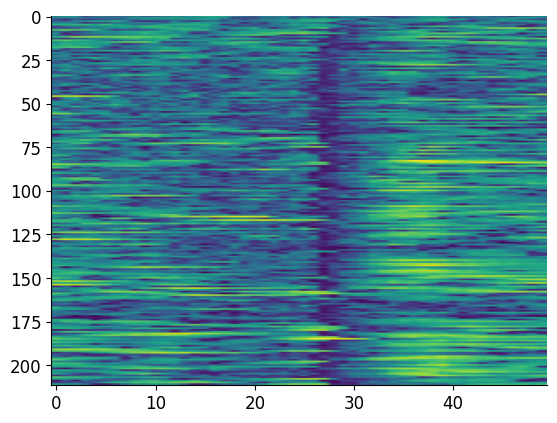

In [37]:
plt.imshow(velocity.T, aspect='auto')


combined_activity.shape (50, 212) 


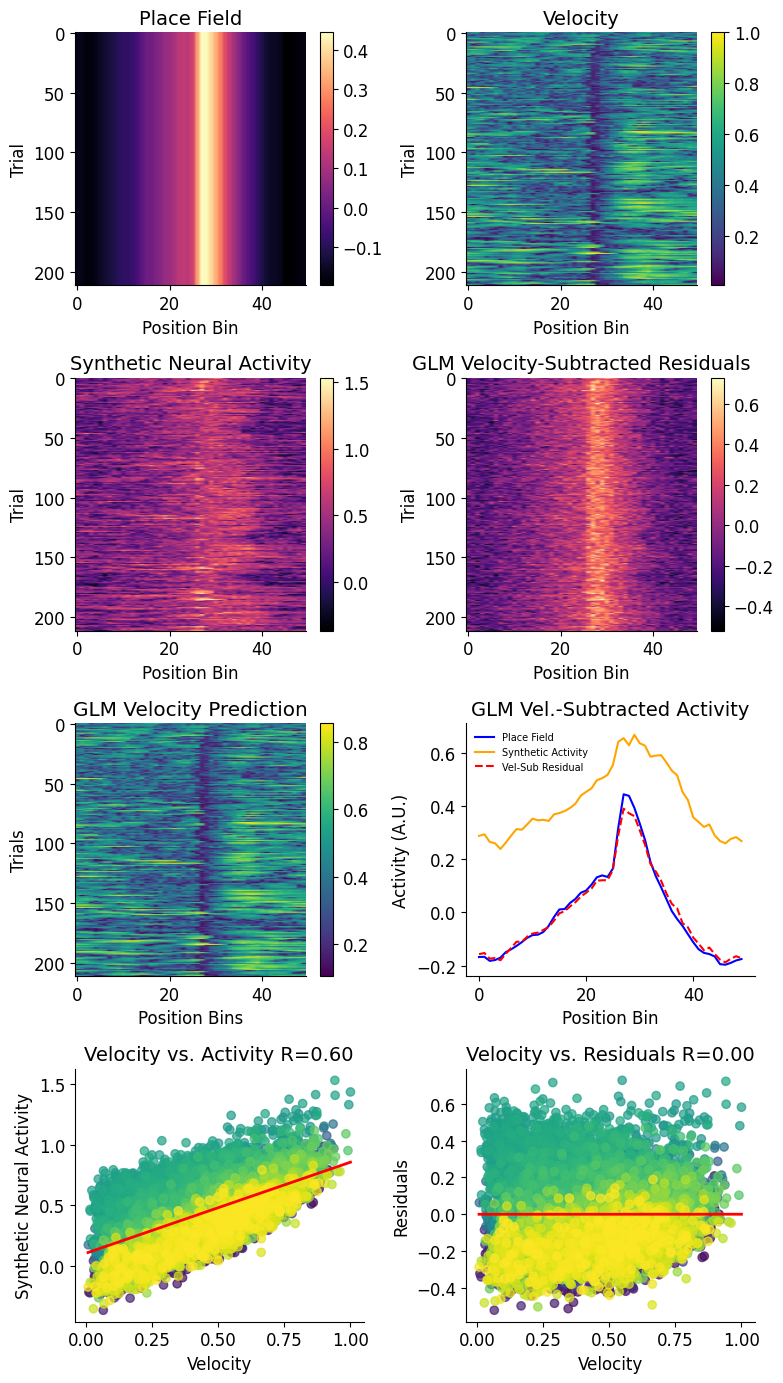

In [38]:
########## plotting synthetic model to show GLM efficacy 

# options for velocity_weight_type = ramping_weight or flat_weight

# options for place field type = "flat", "positive_ramp", "negative_ramp", "step", "BTSP", "EC"
    
# MSE_activity, MSE_residual, MSE_divided, velocity_weight, place_field, velocity, residual, combined_activity, divided_array, predicted_array, place_field_type, z_score = get_synthetic_data(activity_dict_SST, factors_dict_SST, velocity_weight_type="ramping_weight", noise_scale=0.1, place_field_type="flat", velocity_power=1, velocity_weight=1, place_field_shift=0, place_field_scale=0, z_score=False)


MSE_activity, MSE_residual, MSE_divided, velocity_weight, place_field, velocity, residual, combined_activity, divided_array, predicted_array, place_field_type, z_score = get_synthetic_data2(activity_dict_SST, factors_dict_SST, velocity_weight_type="ramping_weight", noise_scale=0.1, place_field_type="flat", velocity_power=1, velocity_weight=1, place_field_shift=0, place_field_scale=5, z_score=False)

plot_synthetic_data_seperate_quintiles(MSE_activity, MSE_residual, MSE_divided, place_field, velocity, residual, combined_activity, divided_array, predicted_array, velocity_weight, place_field_type=place_field_type, z_score=z_score)
        

In [39]:
print(f"np.array_equal(array1, array2): {np.array_equal(velocity, predicted_array)}")

np.array_equal(array1, array2): False


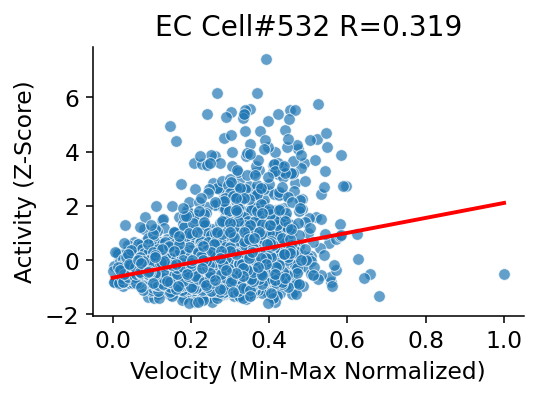

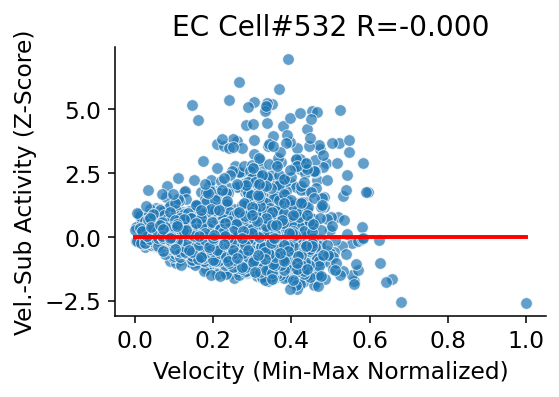

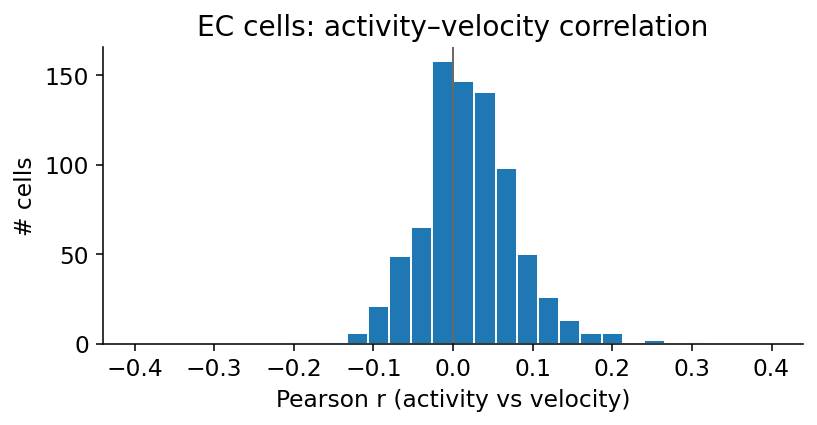

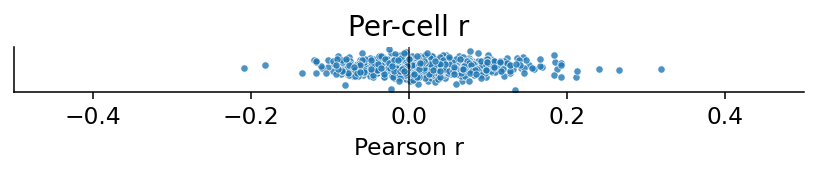

In [37]:
def get_correlations_per_cell(activity_dict_EC, factors_dict_EC):
    activity_per_cell = []
    vel_per_cell = []
    correlations_per_cell = []
    for animal in activity_dict_EC:
        vel = factors_dict_EC[animal]['Velocity']
        for cell in activity_dict_EC[animal]:
            data = activity_dict_EC[animal][cell]
            vel_flat = vel.flatten()
            correlations = []
            flat_data = data.flatten()
            activity_per_cell.append(flat_data)
            vel_per_cell.append(vel_flat)
            r_val, _ = pearsonr(flat_data, vel_flat)
            correlations.append(r_val)
            mean_corr = np.mean(correlations)
            correlations_per_cell.append(mean_corr)
    correlations_per_cell = np.array(correlations_per_cell)
    return correlations_per_cell, activity_per_cell, vel_per_cell



correlations_per_cell, activity_per_cell, vel_per_cell = get_correlations_per_cell(activity_dict_EC, factors_dict_EC)

def plot_one_cell_activity_velocity(correlations_per_cell, vel_per_cell, activity_per_cell, ylabel='Activity (Z-Score)'):
    max_corr = np.argmax(correlations_per_cell)

    x = vel_per_cell[max_corr]
    y = activity_per_cell[max_corr]

    # Fit line of best fit
    slope, intercept, r_val, p_value, std_err = linregress(x, y)
    line_x = np.linspace(x.min(), x.max(), 200)
    line_y = slope * line_x + intercept

    # Plot
    plt.figure(figsize=(4, 3), dpi=140)
    plt.scatter(x, y, alpha=0.7, edgecolor='white', linewidth=0.5)
    plt.plot(line_x, line_y, color='red', lw=2, label=f'Best fit (R²={r_val**2:.2f})')
    plt.xlabel("Velocity (Min-Max Normalized)")
    plt.ylabel(ylabel)
    plt.title(f"EC Cell#{max_corr} R={r_val:.3f}")
    plt.tight_layout()
    plt.show()


plot_one_cell_activity_velocity(correlations_per_cell, vel_per_cell, activity_per_cell, ylabel='Activity (Z-Score)')

residual_list = []

for animal in residual_activity_dict_EC:
    for cell in residual_activity_dict_EC[animal]:
        residual_list.append(residual_activity_dict_EC[animal][cell].flatten())

plot_one_cell_activity_velocity(correlations_per_cell, vel_per_cell, residual_list, ylabel='Vel.-Sub Activity (Z-Score)')




bins = np.linspace(-0.4, 0.4, 31)

plt.figure(figsize=(6,3.2), dpi=140)
plt.hist(correlations_per_cell, bins=bins, edgecolor='white')
plt.axvline(0, color='k', lw=1, alpha=0.6)
plt.xlabel('Pearson r (activity vs velocity)')
plt.ylabel('# cells')
plt.title('EC cells: activity–velocity correlation')
plt.tight_layout()

# optional: show individual r’s as a jittered strip
plt.figure(figsize=(6,1.4), dpi=140)
x = correlations_per_cell
jx = x
jy = np.zeros_like(x) + 0.0
rng = np.random.default_rng(0)
jy += rng.normal(scale=0.02, size=x.size)
plt.scatter(jx, jy, s=14, alpha=0.8, edgecolor='white', linewidth=0.4)
plt.yticks([]); plt.xlabel('Pearson r'); plt.xlim(-0.5, 0.5)
plt.axvline(0, color='k', lw=1, alpha=0.6)
plt.title('Per-cell r')
plt.tight_layout()


In [ ]:
for animal in residual_activity_dict_EC:
    for cell in residual_activity_dict_EC[animal]:
        

n cells: 792


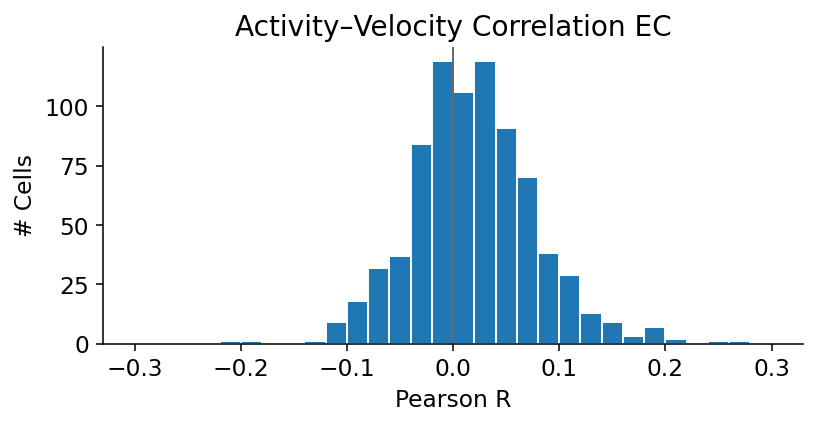

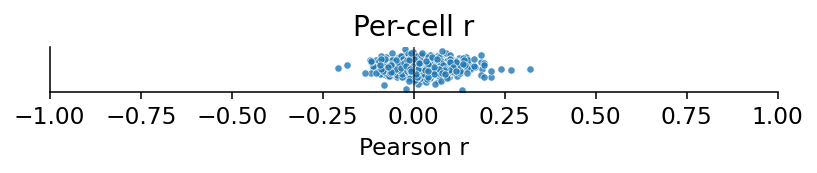

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def corr_vs_velocity_per_cell(activity_dict_EC, factors_dict_EC, verbose=False):
    r_list = []
    for animal, cells in activity_dict_EC.items():
        vel = np.asarray(factors_dict_EC[animal]['Velocity'])
        for cell, data in cells.items():
            A = np.asarray(data)             # shape (pos_bins, trials) or similar
            # Align velocity to data
            if vel.ndim == 1:
                if vel.size == A.shape[0]:
                    v = np.tile(vel, A.shape[1])     # per-bin vel, tile across trials
                elif vel.size == A.shape[1]:
                    v = np.repeat(vel, A.shape[0])   # per-trial vel, repeat across bins
                elif vel.size == A.size:
                    v = vel
                else:
                    if verbose:
                        print(f"skip {animal}/{cell}: vel {vel.shape} vs data {A.shape}")
                    continue
            else:
                v = vel.ravel()
                if v.size != A.size:
                    if verbose:
                        print(f"skip {animal}/{cell}: vel {vel.shape} vs data {A.shape}")
                    continue

            r, p = pearsonr(A.ravel(), v.ravel())
            r_list.append(r)
    return np.array(r_list, dtype=float)

# --- compute ---
correlations_per_cell = corr_vs_velocity_per_cell(activity_dict_EC, factors_dict_EC)
print("n cells:", correlations_per_cell.size)

# --- plot: histogram + jittered strip on top ---
bins = np.linspace(-0.3, 0.3, 31)

plt.figure(figsize=(6,3.2), dpi=140)
plt.hist(correlations_per_cell, bins=bins, edgecolor='white')
plt.axvline(0, color='k', lw=1, alpha=0.6)
plt.xlabel('Pearson R')
plt.ylabel('# Cells')
plt.title('Activity–Velocity Correlation EC')
plt.tight_layout()

# optional: show individual r’s as a jittered strip
plt.figure(figsize=(6,1.4), dpi=140)
x = correlations_per_cell
jx = x
jy = np.zeros_like(x) + 0.0
rng = np.random.default_rng(0)
jy += rng.normal(scale=0.02, size=x.size)
plt.scatter(jx, jy, s=14, alpha=0.8, edgecolor='white', linewidth=0.4)
plt.yticks([]); plt.xlabel('Pearson r'); plt.xlim(-1, 1)
plt.axvline(0, color='k', lw=1, alpha=0.6)
plt.title('Per-cell r')
plt.tight_layout()


In [12]:
factors_dict_EC

{'animal_1': {'Licks': array([[0.41245421, 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         ...,
         [0.34413203, 0.49598669, 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.17790183, 0.        , 0.25307162, ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ]]),
  'Reward_loc': array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]),
  'Velocity': array([[0.15195272, 0.68704282, 0.59094632, ..., 0.58844563, 0.13726014,
          0.625406